# v13 — Momentum Chain Exhaustion: apa yang harus dilakukan saat chain sudah maksimal (8/8)?

**Latar belakang:** analisis trade log v12 (de-redundant scoring, threshold=9.0, TEST out-of-
sample) menemukan pola baru setelah filter Order Block (v10-SKIP) berhasil menghilangkan order
block sbg penyebab LOSS: **entry dengan `momentum_chain` sudah di titik MAKSIMAL (chain=8/8, skala
`bull_chain`/`bear_chain` 0-8 dari `add_momentum_chain(n=4)`, yaitu 4 candle HH+HL atau LL+LH
beruntun) justru win rate PALING RENDAH** dibanding chain yang kuat tapi belum maksimal:

| Chain strength (dominant driver momentum_chain, TEST v12) | n | win rate |
|---|---|---|
| 6/8 | 11 | 63.6% |
| 7/8 | 43 | 76.7% |
| **8/8 (maksimal)** | 48 | **52.1%** |

Ini pola **momentum exhaustion** klasik — kalau harga sudah bergerak searah 4 candle beruntun
penuh (HH+HL atau LL+LH semua), itu justru tanda pergerakan sudah "kepanjangan"/matang, rawan
koreksi/reversal, bukan sinyal kuat untuk entry baru. Tapi `score_momentum_chain()` saat ini
menormalisasi linear (`min(chain/8, 1.0)`) — chain 8/8 justru dapat skor TERTINGGI, kebalikan dari
yang seharusnya kalau exhaustion ini benar.

**Pertanyaan riset (instruksi user):** begitu chain 8/8 terdeteksi bersamaan dengan sinyal lain yang
cukup kuat untuk entry, apa yang seharusnya dilakukan robot?
1. **SKIP** — jangan entry sama sekali (konsisten dgn keputusan Order Block v10)
2. **REVERSE** — balik arah (ikuti logika exhaustion: momentum abis, harga kemungkinan berbalik)
3. **SMALL-PROFIT** — tetap entry, tapi TP/SL kecil (scalp jendela sebelum reversal, spt eksperimen
   small-reverse Order Block di v10, meski itu akhirnya gagal validasi)

**Metodologi (belajar dari 2x kegagalan overfitting REVERSE/SMALL-REVERSE di v10):**
1. Validasi dulu pola chain 8/8 = win rate rendah itu KONSISTEN di seluruh data (TRAIN 2025-01 s/d
   2026-02, bukan cuma TEST tempat ditemukan) sebelum coba solusi apa pun
2. Threshold/parameter tiap varian solusi (mis. TP/SL small-profit) dicari HANYA di TRAIN
3. TEST (2026-03 s/d 2026-08) dipakai HANYA validasi independen, tidak di-tuning ulang
4. Base strategy tetap v12 (de-redundant scoring, threshold=9.0) + v10-SKIP (Order Block) —
   v13 cuma menambah 1 percabangan baru utk kondisi chain 8/8, tidak mengubah yang lain

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals.scoring import (
    score_adx, score_bb, score_cci, score_candle, score_extra_patterns,
    score_fibonacci, score_ichimoku, score_macd, score_mfi, score_momentum_chain,
    score_obv, score_psar, score_rsi, score_rsi_divergence, score_sma, score_smc,
    score_stoch, score_supertrend, score_vwap, score_williams_r,
)

STRATEGY_NAME = "m5_scalping"
VERSION = "v13"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (sama seperti v06/v10/v12)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

BACKTEST_START = "2025-01-01"
TRAIN_END = "2026-03-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)
print("M5 + konteks H1:", df_bt.shape, df_bt["datetime"].min(), "->", df_bt["datetime"].max())

M5 + konteks H1: (107336, 159) 2025-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Scoring v12 (de-redundant) — reuse persis dari notebook v12

In [3]:
OSCILLATOR_CLUSTER = ["rsi", "stoch", "williams_r", "cci", "bb", "vwap"]
TREND_CLUSTER = ["sma", "ichimoku", "supertrend"]
OLD_WEIGHTS = {
    "rsi": 1.0, "stoch": 1.0, "williams_r": 1.0, "cci": 1.0, "bb": 1.0, "vwap": 1.5,
    "sma": 1.5, "ichimoku": 2.5, "supertrend": 2.5,
}
OSCILLATOR_WEIGHT = round(np.mean([1.0, 1.0, 1.0, 1.0, 1.0, 1.5]), 2)
TREND_WEIGHT = round(np.mean([1.5, 2.5, 2.5]), 2)

ADX_MIN = 18.0
ATR_MIN_PCT = 0.03
MIN_SIGNAL_SCORE = 9.0


def check_hard_filters(row: pd.Series, close: float) -> bool:
    adx = row.get("adx", 0)
    if adx < ADX_MIN:
        return False
    atr = row.get("atr", 0)
    if close > 0 and (atr / close * 100) < ATR_MIN_PCT:
        return False
    return True


def check_h1_alignment(row: pd.Series, direction: str) -> bool:
    h1_ema_50 = row.get("h1_ema_50")
    h1_ema_200 = row.get("h1_ema_200")
    if h1_ema_50 is None or h1_ema_200 is None or pd.isna(h1_ema_50) or pd.isna(h1_ema_200):
        return True
    h1_trend = "UP" if h1_ema_50 > h1_ema_200 else ("DOWN" if h1_ema_50 < h1_ema_200 else "FLAT")
    if direction == "BUY" and h1_trend == "DOWN":
        return False
    if direction == "SELL" and h1_trend == "UP":
        return False
    return True


def has_opposing_ob(row: pd.Series, direction: str) -> bool:
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def score_de_redundant(row: pd.Series) -> float:
    close = float(row["close"])
    atr = float(row.get("atr", close * 0.001))
    raw_scores = {
        "rsi": score_rsi(row)[0] / OLD_WEIGHTS["rsi"],
        "stoch": score_stoch(row)[0] / OLD_WEIGHTS["stoch"],
        "williams_r": score_williams_r(row)[0] / OLD_WEIGHTS["williams_r"],
        "cci": score_cci(row)[0] / OLD_WEIGHTS["cci"],
        "bb": score_bb(row, close)[0] / OLD_WEIGHTS["bb"],
        "vwap": score_vwap(row, close)[0] / OLD_WEIGHTS["vwap"],
        "sma": score_sma(row, close)[0] / OLD_WEIGHTS["sma"],
        "ichimoku": score_ichimoku(row, close)[0] / OLD_WEIGHTS["ichimoku"],
        "supertrend": score_supertrend(row)[0] / OLD_WEIGHTS["supertrend"],
    }
    oscillator_raw = np.median([raw_scores[c] for c in OSCILLATOR_CLUSTER])
    trend_raw = np.median([raw_scores[c] for c in TREND_CLUSTER])
    components = {
        "oscillator_composite": oscillator_raw * OSCILLATOR_WEIGHT,
        "trend_composite": trend_raw * TREND_WEIGHT,
        "macd": score_macd(row)[0],
        "adx": score_adx(row)[0],
        "candle": score_candle(row)[0],
        "extra_patterns": score_extra_patterns(row)[0],
        "obv": score_obv(row)[0],
        "mfi": score_mfi(row)[0],
        "fibonacci": score_fibonacci(row, close, atr)[0],
        "rsi_divergence": score_rsi_divergence(row)[0],
        "momentum_chain": score_momentum_chain(row)[0],
        "psar": score_psar(row)[0],
        "smc": score_smc(row)[0],
    }
    return round(sum(components.values()), 3)


print("Computing v12 scores utk SEMUA candle (TRAIN+TEST, ~107K baris)... akan makan beberapa menit.")
scores = []
for _, row in df_bt.iterrows():
    close = float(row["close"])
    if not check_hard_filters(row, close):
        scores.append(np.nan)
        continue
    scores.append(score_de_redundant(row))
df_bt["v12_raw_score"] = scores
print("Done. Non-null:", df_bt["v12_raw_score"].notna().sum())

Computing v12 scores utk SEMUA candle (TRAIN+TEST, ~107K baris)... akan makan beberapa menit.


Done. Non-null: 76825


## 3. Bangun sinyal v12 final (threshold=9.0 + H1 alignment + Order Block SKIP)

In [4]:
score = df_bt["v12_raw_score"]
direction_col = pd.Series("WAIT", index=df_bt.index)
direction_col[score >= MIN_SIGNAL_SCORE] = "BUY"
direction_col[score <= -MIN_SIGNAL_SCORE] = "SELL"

for idx in direction_col[direction_col != "WAIT"].index:
    row = df_bt.loc[idx]
    d = direction_col.loc[idx]
    if not check_h1_alignment(row, d) or has_opposing_ob(row, d):
        direction_col.loc[idx] = "WAIT"

df_bt["signal_direction"] = direction_col
print("Total sinyal v12 (BUY+SELL):", (df_bt["signal_direction"] != "WAIT").sum())
print(df_bt["signal_direction"].value_counts())

Total sinyal v12 (BUY+SELL): 1181
signal_direction
WAIT    106155
BUY        831
SELL       350
Name: count, dtype: int64


## 4. Validasi pola chain 8/8 di SELURUH data (TRAIN+TEST) — bukan cuma di TEST tempat ditemukan

`dominant_chain`: nilai bull_chain (kalau BUY) atau bear_chain (kalau SELL) -- searah arah sinyal.

In [5]:
sig = df_bt[df_bt["signal_direction"] != "WAIT"].copy()
sig["dominant_chain"] = np.where(
    sig["signal_direction"] == "BUY", sig["bull_chain"], sig["bear_chain"]
)
sig["chain_maxed"] = sig["dominant_chain"] >= 8

print("Distribusi dominant_chain di semua sinyal v12 (TRAIN+TEST):")
print(sig["dominant_chain"].value_counts().sort_index())
print()
print(f"Total sinyal dgn chain maxed (8/8): {sig['chain_maxed'].sum()} dari {len(sig)} "
      f"({sig['chain_maxed'].mean()*100:.1f}%)")

Distribusi dominant_chain di semua sinyal v12 (TRAIN+TEST):
dominant_chain
3.0      1
4.0     28
5.0    138
6.0    306
7.0    313
8.0    395
Name: count, dtype: int64

Total sinyal dgn chain maxed (8/8): 395 dari 1181 (33.4%)


## 5. Backtest engine — mode baseline (v12+SKIP OB murni) vs 3 varian penanganan chain 8/8

In [6]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30
SL_MULT = 2.0
TP_MULT = 4.0
MAX_HOLD_CANDLES = 12
MAX_HOLD_SMALL_CANDLES = 6

RAW_INDICATOR_COLUMNS = [c for c in df_bt.columns if c not in ("timestamp", "datetime", "v12_raw_score", "signal_direction", "h1_available_at")]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def run_backtest(
    df_signals: pd.DataFrame,
    mode: str,  # "baseline" | "skip" | "reverse" | "small_profit"
    sl_mult_small: float = 1.0, tp_mult_small: float = 1.5,
    save_full_log: bool = False,
) -> tuple[pd.DataFrame, list[float]]:
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        original_direction = row["signal_direction"]

        if original_direction == "WAIT":
            i += 1
            continue

        dominant_chain = row["bull_chain"] if original_direction == "BUY" else row["bear_chain"]
        chain_maxed = dominant_chain >= 8

        direction = original_direction
        is_special = False
        cur_sl_mult, cur_tp_mult, cur_max_hold = SL_MULT, TP_MULT, MAX_HOLD_CANDLES

        if chain_maxed:
            if mode == "skip":
                i += 1
                continue
            if mode == "reverse":
                direction = "SELL" if original_direction == "BUY" else "BUY"
                is_special = True
            if mode == "small_profit":
                is_special = True
                cur_sl_mult, cur_tp_mult, cur_max_hold = sl_mult_small, tp_mult_small, MAX_HOLD_SMALL_CANDLES
            # mode == "baseline": biarkan direction = original_direction (abaikan exhaustion)

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = cur_sl_mult * atr
        tp_points = cur_tp_mult * atr
        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + tp_points
            sl_price = entry_price - sl_points
        else:
            tp_price = entry_price - tp_points
            sl_price = entry_price + sl_points

        lot = calc_lot(equity, RISK_PCT, sl_points)
        equity_before = equity

        exit_price: float | None = None
        exit_reason = None
        exit_idx = min(i + cur_max_hold, n - 1)

        window_end = min(i + 1 + cur_max_hold, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                exit_idx = candle_idx
                break

        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"

        next_i = exit_idx + 1
        hold_candles = exit_idx - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time, "exit_time": exit_time,
            "original_direction": original_direction, "direction": direction,
            "chain_maxed": chain_maxed, "is_special": is_special, "dominant_chain": dominant_chain,
            "entry_price": entry_price, "exit_price": exit_price, "tp_price": tp_price, "sl_price": sl_price,
            "atr_at_entry": atr, "sl_points": sl_points, "tp_points": tp_points,
            "lot": lot, "hold_candles": hold_candles, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "signal_score": row["v12_raw_score"], "equity_before": equity_before, "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

## 6. TRAIN (2025-01 s/d 2026-02): validasi pola + grid search SMALL-PROFIT

In [7]:
df_train = df_bt[df_bt["datetime"] < TRAIN_END].reset_index(drop=True)
df_test = df_bt[df_bt["datetime"] >= TRAIN_END].reset_index(drop=True)
print(f"TRAIN: {len(df_train)} baris, TEST: {len(df_test)} baris")

trades_train_baseline, _ = run_backtest(df_train, mode="baseline")
metrics_train_baseline = evaluate(trades_train_baseline, INITIAL_EQUITY)
print("\n=== TRAIN: baseline (abaikan chain exhaustion) ===")
for k, v in metrics_train_baseline.items():
    print(f"  {k}: {v}")

chain_maxed_train = trades_train_baseline[trades_train_baseline["chain_maxed"]]
chain_not_maxed_train = trades_train_baseline[~trades_train_baseline["chain_maxed"]]
print(f"\nWin rate chain MAXED (TRAIN): n={len(chain_maxed_train)}, "
      f"win_rate={(chain_maxed_train['pnl']>0).mean()*100:.1f}%, net_pnl={chain_maxed_train['pnl'].sum():.2f}")
print(f"Win rate chain TIDAK maxed (TRAIN): n={len(chain_not_maxed_train)}, "
      f"win_rate={(chain_not_maxed_train['pnl']>0).mean()*100:.1f}%, net_pnl={chain_not_maxed_train['pnl'].sum():.2f}")

TRAIN: 77226 baris, TEST: 30110 baris



=== TRAIN: baseline (abaikan chain exhaustion) ===
  total_trades: 507
  win_rate_pct: 64.89
  profit_factor: 2.9
  net_pnl: 1972.55
  final_equity: 2072.55
  max_drawdown_pct: -7.24
  min_equity: 97.67
  trading_days: 221
  avg_daily_pnl: 8.93
  avg_trades_per_day: 2.29

Win rate chain MAXED (TRAIN): n=131, win_rate=64.9%, net_pnl=545.10
Win rate chain TIDAK maxed (TRAIN): n=376, win_rate=64.9%, net_pnl=1427.45


In [8]:
trades_train_skip, _ = run_backtest(df_train, mode="skip")
metrics_train_skip = evaluate(trades_train_skip, INITIAL_EQUITY)

trades_train_reverse, _ = run_backtest(df_train, mode="reverse")
metrics_train_reverse = evaluate(trades_train_reverse, INITIAL_EQUITY)
reversed_train = trades_train_reverse[trades_train_reverse["is_special"]]

print("=== TRAIN: SKIP saat chain maxed ===")
for k, v in metrics_train_skip.items():
    print(f"  {k}: {v}")
print("\n=== TRAIN: REVERSE saat chain maxed ===")
for k, v in metrics_train_reverse.items():
    print(f"  {k}: {v}")
print(f"  win_rate trade reverse: {(reversed_train['pnl']>0).mean()*100:.1f}% (n={len(reversed_train)})")

=== TRAIN: SKIP saat chain maxed ===
  total_trades: 396
  win_rate_pct: 65.4
  profit_factor: 2.78
  net_pnl: 1407.48
  final_equity: 1507.48
  max_drawdown_pct: -9.03
  min_equity: 97.67
  trading_days: 198
  avg_daily_pnl: 7.11
  avg_trades_per_day: 2.0

=== TRAIN: REVERSE saat chain maxed ===
  total_trades: 516
  win_rate_pct: 52.91
  profit_factor: 1.5
  net_pnl: 714.14
  final_equity: 814.14
  max_drawdown_pct: -15.26
  min_equity: 95.71
  trading_days: 221
  avg_daily_pnl: 3.23
  avg_trades_per_day: 2.33
  win_rate trade reverse: 18.4% (n=136)


In [9]:
sl_small_candidates = [0.5, 0.75, 1.0, 1.25]
tp_small_candidates = [0.5, 0.75, 1.0, 1.5, 2.0]

grid_results = []
for sl_s in sl_small_candidates:
    for tp_s in tp_small_candidates:
        trades, _ = run_backtest(df_train, mode="small_profit", sl_mult_small=sl_s, tp_mult_small=tp_s)
        metrics = evaluate(trades, INITIAL_EQUITY)
        special_trades = trades[trades["is_special"]]
        metrics.update({
            "sl_mult_small": sl_s, "tp_mult_small": tp_s,
            "n_special": len(special_trades),
            "special_win_rate": round((special_trades["pnl"] > 0).mean() * 100, 1) if len(special_trades) else None,
            "special_net_pnl": round(special_trades["pnl"].sum(), 2) if len(special_trades) else 0,
        })
        grid_results.append(metrics)

grid_df = pd.DataFrame(grid_results).sort_values("profit_factor", ascending=False)
print("=== TRAIN grid search SMALL-PROFIT (diurutkan by profit_factor) ===")
grid_df.head(10)

=== TRAIN grid search SMALL-PROFIT (diurutkan by profit_factor) ===


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,sl_mult_small,tp_mult_small,n_special,special_win_rate,special_net_pnl
17,525,68.95,3.12,1992.23,2092.23,-5.69,97.67,221,9.01,2.38,1.25,1.00,138,78.3,459.15
12,525,67.62,3.08,2071.67,2171.67,-5.78,97.67,221,9.37,2.38,1.00,1.00,138,73.2,515.39
16,526,70.34,3.06,1884.47,1984.47,-5.89,97.67,221,8.53,2.38,1.25,0.75,139,83.5,364.83
18,523,66.54,3.06,2074.48,2174.48,-5.78,97.67,221,9.39,2.37,1.25,1.50,136,69.9,520.52
13,523,65.20,3.03,2174.54,2274.54,-5.91,97.67,221,9.84,2.37,1.00,1.50,136,64.7,617.82
14,522,63.79,3.00,2206.23,2306.23,-8.15,97.67,221,9.98,2.36,1.00,2.00,136,58.8,646.00
11,526,69.01,2.98,1924.25,2024.25,-5.87,97.67,221,8.71,2.38,1.00,0.75,139,78.4,387.57
19,522,64.75,2.96,2010.81,2110.81,-5.73,97.67,221,9.10,2.36,1.25,2.00,136,62.5,524.23
15,530,71.51,2.95,1689.11,1789.11,-6.75,97.67,221,7.64,2.40,1.25,0.50,143,87.4,243.73
10,530,70.19,2.81,1672.23,1772.23,-6.75,97.67,221,7.57,2.40,1.00,0.50,143,82.5,226.39


## 7. Validasi TEST (out-of-sample) — parameter FIXED dari TRAIN, tiga varian dibandingkan

In [10]:
trades_test_baseline, curve_test_baseline = run_backtest(df_test, mode="baseline")
metrics_test_baseline = evaluate(trades_test_baseline, INITIAL_EQUITY)

trades_test_skip, curve_test_skip = run_backtest(df_test, mode="skip")
metrics_test_skip = evaluate(trades_test_skip, INITIAL_EQUITY)

trades_test_reverse, curve_test_reverse = run_backtest(df_test, mode="reverse", save_full_log=True)
metrics_test_reverse = evaluate(trades_test_reverse, INITIAL_EQUITY)
reversed_test = trades_test_reverse[trades_test_reverse["is_special"]]

best_row = grid_df.iloc[0]
SL_SMALL = float(best_row["sl_mult_small"])
TP_SMALL = float(best_row["tp_mult_small"])
print(f"Parameter small-profit terpilih dari TRAIN: SL={SL_SMALL}x, TP={TP_SMALL}x ATR")

trades_test_small, curve_test_small = run_backtest(
    df_test, mode="small_profit", sl_mult_small=SL_SMALL, tp_mult_small=TP_SMALL, save_full_log=True
)
metrics_test_small = evaluate(trades_test_small, INITIAL_EQUITY)
special_test_small = trades_test_small[trades_test_small["is_special"]]

comparison = pd.DataFrame({
    "baseline (abaikan exhaustion)": metrics_test_baseline,
    "SKIP saat chain maxed": metrics_test_skip,
    "REVERSE saat chain maxed": metrics_test_reverse,
    f"SMALL-PROFIT (sl={SL_SMALL},tp={TP_SMALL})": metrics_test_small,
})
print("\n=== Perbandingan TEST set (out-of-sample), empat varian ===")
comparison

Parameter small-profit terpilih dari TRAIN: SL=1.25x, TP=1.0x ATR



=== Perbandingan TEST set (out-of-sample), empat varian ===


,baseline (abaikan exhaustion),SKIP saat chain maxed,REVERSE saat chain maxed,"SMALL-PROFIT (sl=1.25,tp=1.0)"
total_trades,192.00,145.00,192.00,196.00
win_rate_pct,68.75,74.48,60.42,75.00
profit_factor,3.20,3.85,2.02,3.57
net_pnl,1193.09,1084.14,751.98,1178.82
final_equity,1293.09,1184.14,851.98,1278.82
max_drawdown_pct,-41.33,-34.45,-45.22,-34.18
min_equity,66.79,74.62,62.37,74.93
trading_days,89.00,83.00,89.00,89.00
avg_daily_pnl,13.41,13.06,8.45,13.25
avg_trades_per_day,2.16,1.75,2.16,2.20


In [11]:
print("=== Detail performa trade khusus (yang kena chain-maxed handling) di TEST ===")
print(f"REVERSE: n={len(reversed_test)}, win_rate={(reversed_test['pnl']>0).mean()*100:.1f}%, "
      f"net_pnl={reversed_test['pnl'].sum():.2f}" if len(reversed_test) else "REVERSE: no trades")
print(f"SMALL-PROFIT: n={len(special_test_small)}, win_rate={(special_test_small['pnl']>0).mean()*100:.1f}%, "
      f"net_pnl={special_test_small['pnl'].sum():.2f}" if len(special_test_small) else "SMALL-PROFIT: no trades")
print()
print("=== Konsistensi TRAIN vs TEST ===")
print(f"REVERSE win_rate: TRAIN={((reversed_train['pnl']>0).mean()*100):.1f}%, TEST={((reversed_test['pnl']>0).mean()*100):.1f}%" if len(reversed_train) and len(reversed_test) else "n/a")
print(f"SMALL-PROFIT win_rate: TRAIN={best_row['special_win_rate']}%, TEST={(special_test_small['pnl']>0).mean()*100:.1f}%" if len(special_test_small) else "n/a")

=== Detail performa trade khusus (yang kena chain-maxed handling) di TEST ===
REVERSE: n=51, win_rate=23.5%, net_pnl=-241.46
SMALL-PROFIT: n=53, win_rate=77.4%, net_pnl=166.31

=== Konsistensi TRAIN vs TEST ===
REVERSE win_rate: TRAIN=18.4%, TEST=23.5%
SMALL-PROFIT win_rate: TRAIN=78.3%, TEST=77.4%


## 8. Equity curve — TEST set, empat varian

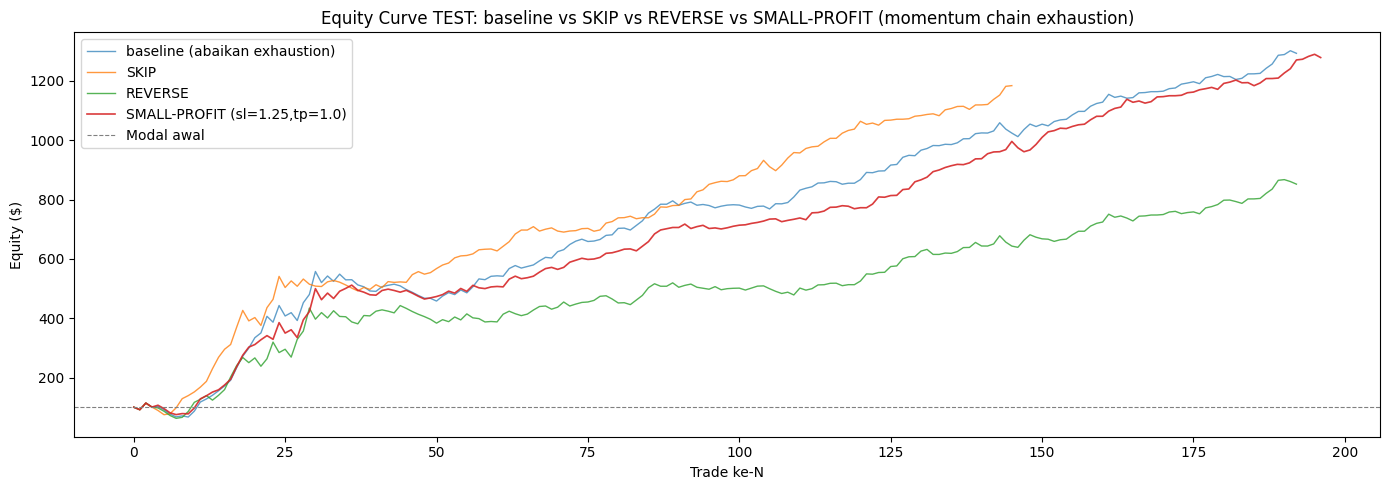

In [12]:
fig, ax = plt.subplots()
ax.plot(curve_test_baseline, label="baseline (abaikan exhaustion)", alpha=0.7, linewidth=1.0)
ax.plot(curve_test_skip, label="SKIP", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_reverse, label="REVERSE", alpha=0.8, linewidth=1.0)
ax.plot(curve_test_small, label=f"SMALL-PROFIT (sl={SL_SMALL},tp={TP_SMALL})", alpha=0.9, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve TEST: baseline vs SKIP vs REVERSE vs SMALL-PROFIT (momentum chain exhaustion)")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve_test_comparison.png", dpi=120)
plt.show()

## 9. Kesimpulan & keputusan

Kriteria: varian terpilih harus lebih baik dari baseline DI TEST, dan konsisten TRAIN vs TEST
(win rate trade khusus tidak boleh merosot jauh — pelajaran dari REVERSE/SMALL-REVERSE Order Block
yang gagal di v10).

In [13]:
print("=== Ringkasan TEST (profit_factor, net_pnl, max_drawdown) ===")
for name, m in [("baseline", metrics_test_baseline), ("SKIP", metrics_test_skip),
                 ("REVERSE", metrics_test_reverse), ("SMALL-PROFIT", metrics_test_small)]:
    print(f"{name:15s}: PF={m['profit_factor']:5.2f}  net_pnl=${m['net_pnl']:8.2f}  "
          f"max_dd={m['max_drawdown_pct']:6.2f}%  win_rate={m['win_rate_pct']:5.1f}%")

=== Ringkasan TEST (profit_factor, net_pnl, max_drawdown) ===
baseline       : PF= 3.20  net_pnl=$ 1193.09  max_dd=-41.33%  win_rate= 68.8%
SKIP           : PF= 3.85  net_pnl=$ 1084.14  max_dd=-34.45%  win_rate= 74.5%
REVERSE        : PF= 2.02  net_pnl=$  751.98  max_dd=-45.22%  win_rate= 60.4%
SMALL-PROFIT   : PF= 3.57  net_pnl=$ 1178.82  max_dd=-34.18%  win_rate= 75.0%


## 10. Simpan hasil

In [14]:
trades_test_small.to_csv(PROCESSED_OUT_DIR / "trade_log_test_small_profit.csv", index=False)
trades_test_reverse.to_csv(PROCESSED_OUT_DIR / "trade_log_test_reverse.csv", index=False)
grid_df.to_csv(EXPORT_DIR / "grid_search_train_small_profit.csv", index=False)
comparison.to_csv(EXPORT_DIR / "comparison_four_variants.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write("Backtest v13 -- Momentum Chain Exhaustion (chain 8/8): SKIP vs REVERSE vs SMALL-PROFIT\n\n")
    f.write(f"SMALL-PROFIT param terpilih dari TRAIN: SL={SL_SMALL}x ATR, TP={TP_SMALL}x ATR\n\n")
    f.write("=== TRAIN (2025-01 s/d 2026-02) ===\n")
    f.write("baseline:\n")
    for k, v in metrics_train_baseline.items():
        f.write(f"  {k}: {v}\n")
    f.write("SKIP:\n")
    for k, v in metrics_train_skip.items():
        f.write(f"  {k}: {v}\n")
    f.write("REVERSE:\n")
    for k, v in metrics_train_reverse.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  win_rate trade reverse: {(reversed_train['pnl']>0).mean()*100:.1f}%\n" if len(reversed_train) else "")
    f.write("\n=== TEST (2026-03 s/d 2026-08, out-of-sample) ===\n")
    for name, m in [("baseline", metrics_test_baseline), ("SKIP", metrics_test_skip),
                     ("REVERSE", metrics_test_reverse), ("SMALL-PROFIT", metrics_test_small)]:
        f.write(f"{name}:\n")
        for k, v in m.items():
            f.write(f"  {k}: {v}\n")
    f.write(f"\nREVERSE trade win_rate TEST: {(reversed_test['pnl']>0).mean()*100:.1f}% (n={len(reversed_test)})\n" if len(reversed_test) else "")
    f.write(f"SMALL-PROFIT trade win_rate TEST: {(special_test_small['pnl']>0).mean()*100:.1f}% (n={len(special_test_small)})\n" if len(special_test_small) else "")

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v13
 - comparison_four_variants.csv
 - equity_curve_test_comparison.png
 - grid_search_train_small_profit.csv
 - metrics.txt
